In [2]:
import os
import sys
sys.path.append("..")  # add project root
import scipy.io as sio
import importlib
from prog import mlps, featlib, trainer, hlprs
importlib.reload(mlps)
import Datasets.load_mat_as_flat as lmf
import Datasets.matconv as mc
import torch
import matplotlib.pyplot as plt
import numpy as np

# What tests will we be doing?

## Test **1**:
We will set $$\lambda_{PDE} = 0$$
So that we are only training on data, to see if the u-net can recover the data.

### Allen Cahn:

Data Generation Settings

In [75]:
device='cpu'

# Data generation settings
path = "../Datasets/data/raw/Allen_Cahn.mat"
noise=0.0
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

In [76]:
data_ac = sio.loadmat("../Datasets/data/raw/Allen_Cahn.mat")
print("t shape:", data_ac['t'].shape)
print("x shape:", data_ac['x'].shape)
print("u shape:", data_ac['u'].shape)
print(data_ac['t'])

t shape: (1, 101)
x shape: (1, 201)
u shape: (101, 201)
[[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
  0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
  0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
  0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
  0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
  0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
  0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
  0.98 0.99 1.  ]]


Loading Data

In [77]:
partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print(t_torch.shape)

torch.Size([20301])


Training Settings

In [10]:
selected_derivs=('u','u_x','u_xx') # up to first order derivative inputs
lr=0.001
batch_size=1000  # number of data points used on optimization step 
                 # data points are generated according to tensor.randint over spacetime mesh
lam_pde=0.0
lam_reg=0.0
lam_tv=0.0
lam_data=10.0

#output settings
log_every=1000

Training

In [11]:
# Initializing u_model and a dummy v_model so that trainer works
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=0, bias=False) # dummy v_model for working code
for param in v_model.parameters(): #freeze v_model params
    param.requires_grad = False
print('v model parameters (weights) are not receiving gradients (improve data fit accuracy)')

train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

c:\Users\Ethan\anaconda3\envs\pythonProject\lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


v model parameters (weights) are not receiving gradients (improve data fit accuracy)


In [13]:
for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                           t_torch=t_torch,
                                           x_torch=x_torch,
                                           y_clean=y_torch,
                                           y_noisy=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.5271005630493164 pde_loss=0.01034555584192276
step 1000 data_loss=0.09632297605276108 pde_loss=1.4369064569473267
step 2000 data_loss=0.0075391861610114574 pde_loss=19.493295669555664
step 3000 data_loss=0.002824832685291767 pde_loss=26.05605125427246


We can see that at 3000 steps, loss is approximately $$2.8*10^{-3}$$

max_abs_diff = 0.41103


()

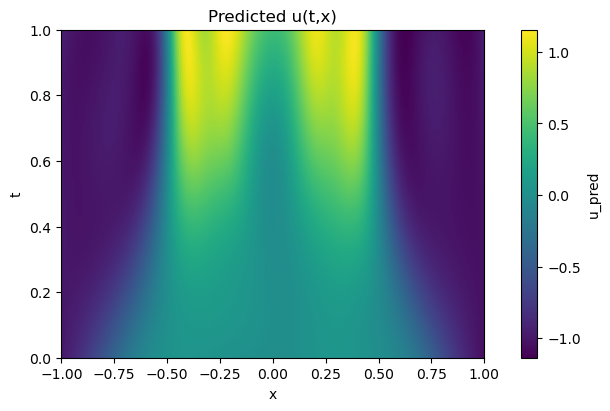

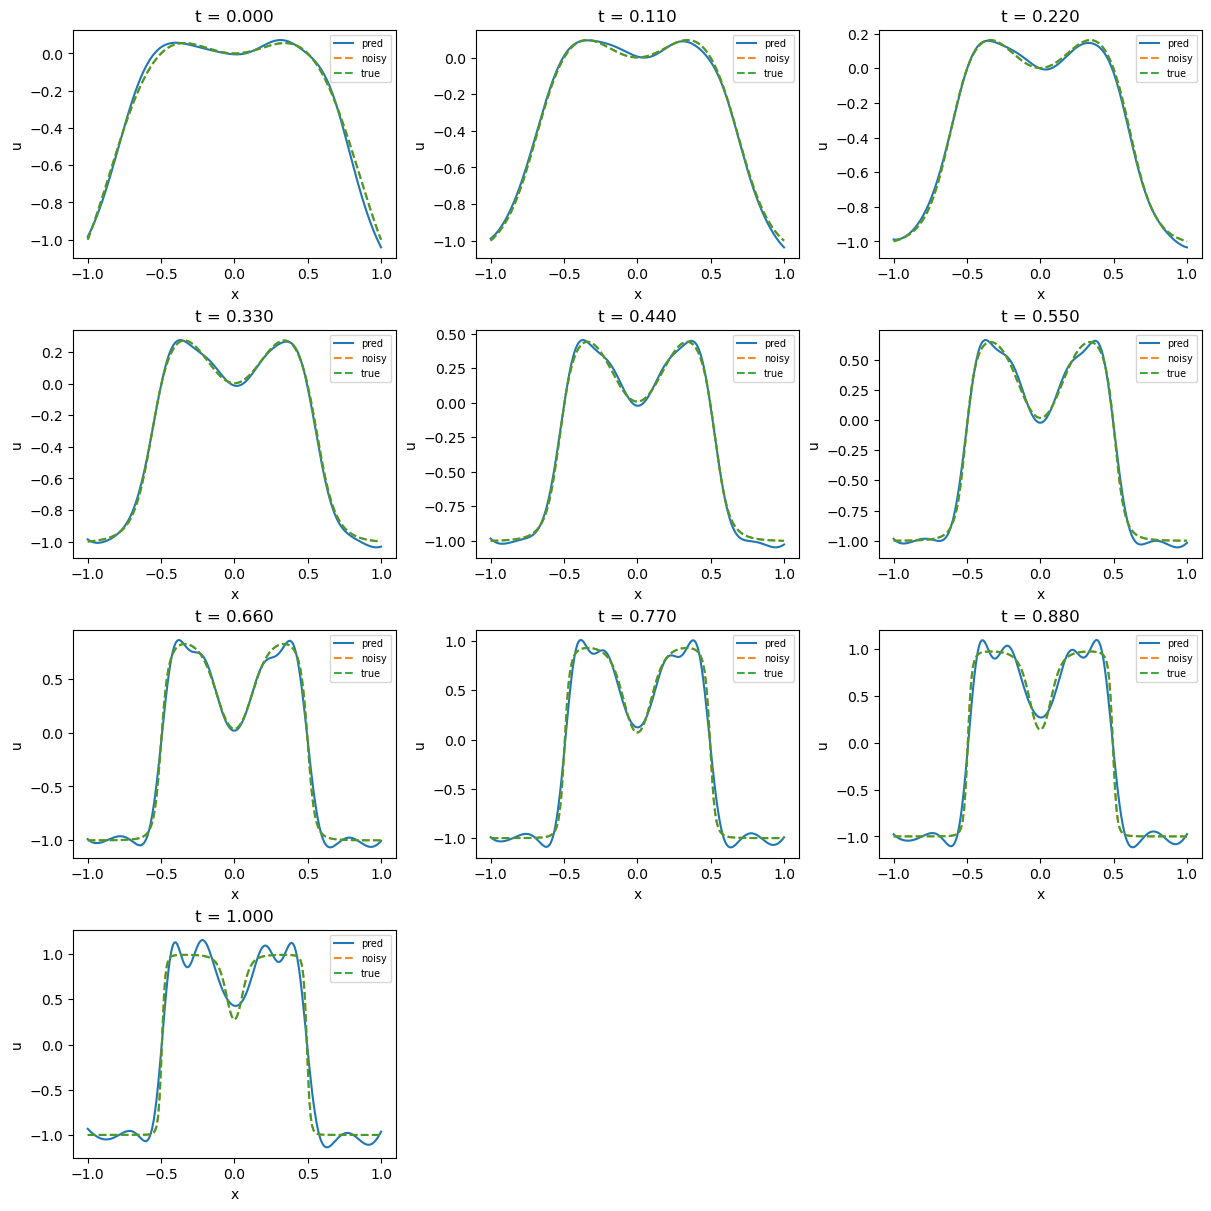

In [14]:
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

### Burgers:
Let's try the same test, but with Burgers' equation with, $$\nu=0.02$$

In [15]:
device='cpu'

# Data generation settings
path = "../Datasets/data/raw/burgers.mat"
noise=0.0
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

In [54]:
data_burgers = sio.loadmat("../Datasets/data/raw/burgers.mat")
print(data_burgers.keys())
print("t shape:", data_burgers['t'].shape)
print("x shape:", data_burgers['x'].shape)
print("usol shape:", data_burgers['usol'].shape)


dict_keys(['__header__', '__version__', '__globals__', 't', 'x', 'usol'])
t shape: (101, 1)
x shape: (1, 256)
usol shape: (256, 101)


In [55]:
partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [56]:
for i in range(len(t_torch)):
    if t_torch[i] == 0.0:
        print("t[{}] = 0.0".format(i))

t[0] = 0.0
t[101] = 0.0
t[202] = 0.0
t[303] = 0.0
t[404] = 0.0
t[505] = 0.0
t[606] = 0.0
t[707] = 0.0
t[808] = 0.0
t[909] = 0.0
t[1010] = 0.0
t[1111] = 0.0
t[1212] = 0.0
t[1313] = 0.0
t[1414] = 0.0
t[1515] = 0.0
t[1616] = 0.0
t[1717] = 0.0
t[1818] = 0.0
t[1919] = 0.0
t[2020] = 0.0
t[2121] = 0.0
t[2222] = 0.0
t[2323] = 0.0
t[2424] = 0.0
t[2525] = 0.0
t[2626] = 0.0
t[2727] = 0.0
t[2828] = 0.0
t[2929] = 0.0
t[3030] = 0.0
t[3131] = 0.0
t[3232] = 0.0
t[3333] = 0.0
t[3434] = 0.0
t[3535] = 0.0
t[3636] = 0.0
t[3737] = 0.0
t[3838] = 0.0
t[3939] = 0.0
t[4040] = 0.0
t[4141] = 0.0
t[4242] = 0.0
t[4343] = 0.0
t[4444] = 0.0
t[4545] = 0.0
t[4646] = 0.0
t[4747] = 0.0
t[4848] = 0.0
t[4949] = 0.0
t[5050] = 0.0


In [17]:
selected_derivs=('u','u_x','u_xx') # up to first order derivative inputs
lr=0.001
batch_size=1000  # number of data points used on optimization step 
                 # data points are generated according to tensor.randint over spacetime mesh
lam_pde=0.0
lam_reg=0.0
lam_tv=0.0
lam_data=10.0

#output settings
log_every=1000

In [18]:
# Initializing u_model and a dummy v_model so that trainer works
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=0, bias=False) # dummy v_model for working code
for param in v_model.parameters(): #freeze v_model params
    param.requires_grad = False
print('v model parameters (weights) are not receiving gradients (improve data fit accuracy)')

train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

v model parameters (weights) are not receiving gradients (improve data fit accuracy)


c:\Users\Ethan\anaconda3\envs\pythonProject\lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [19]:
for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                           t_torch=t_torch,
                                           x_torch=x_torch,
                                           y_clean=y_torch,
                                           y_noisy=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.0667729303240776 pde_loss=0.006120571866631508
step 1000 data_loss=0.00014782330254092813 pde_loss=0.02772153541445732
step 2000 data_loss=4.430514309206046e-05 pde_loss=0.028152253478765488
step 3000 data_loss=2.4556849893997423e-05 pde_loss=0.024639694020152092


max_abs_diff = 0.0610678


()

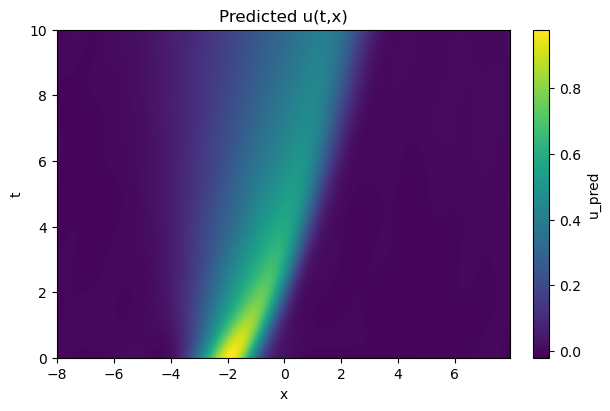

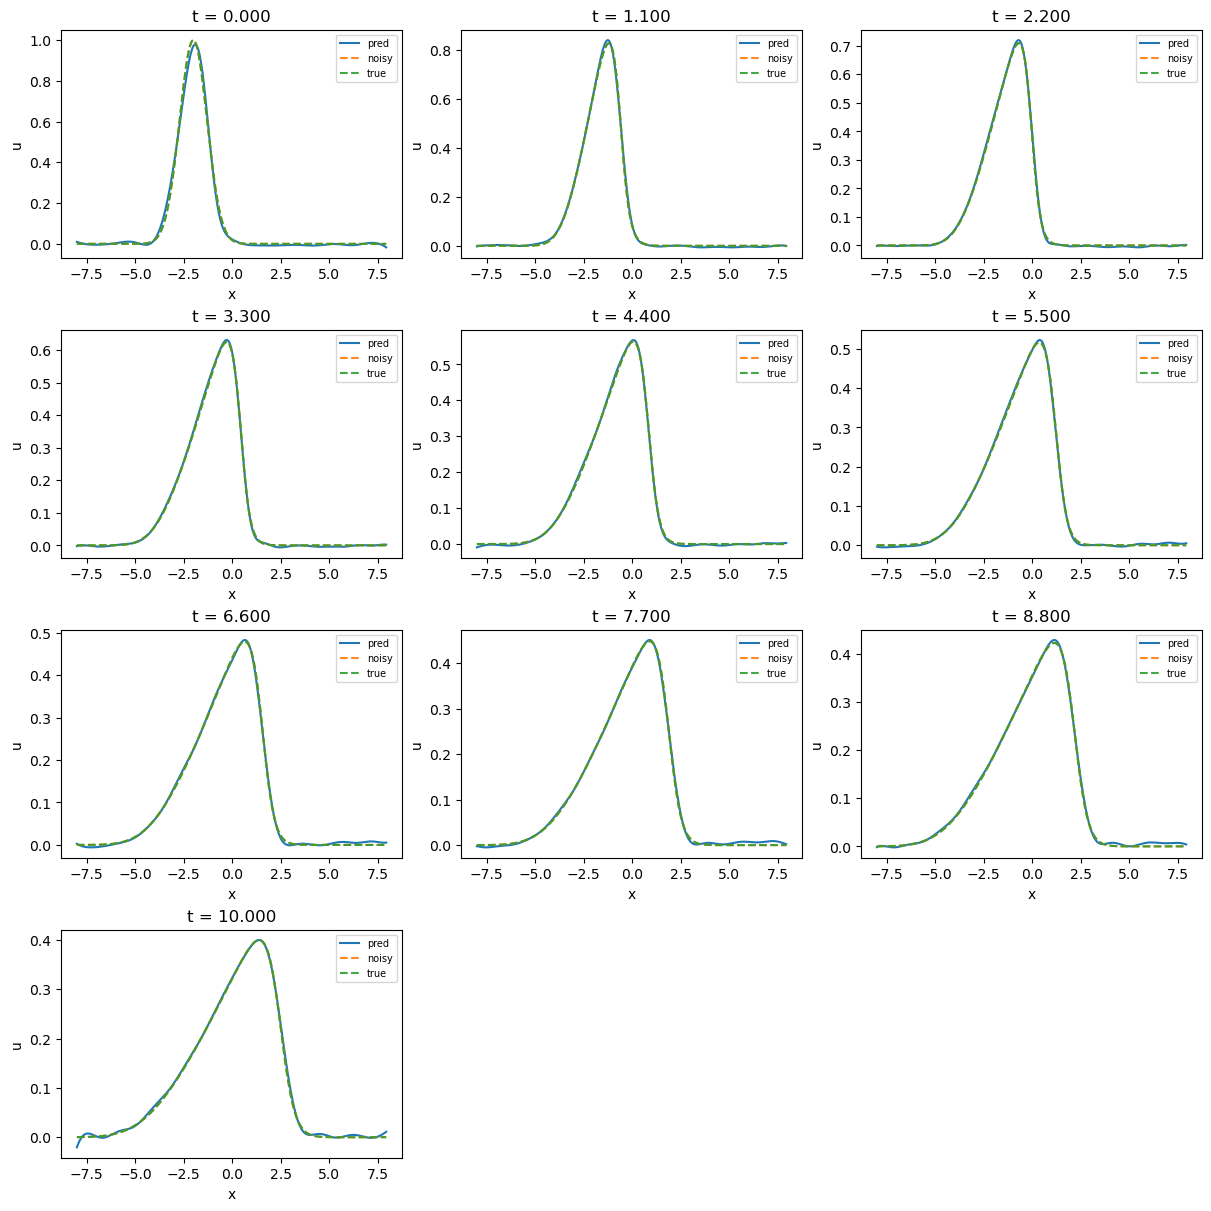

In [20]:
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

Here we can see that at 3000 steps, loss is about 
$$2.5 * 10^{-5}$$
So we get a loss that is about 2 orders of magnitude better for burgers than we did for Allen-Cahn.

right now, burgers.mat u solution has 256 * 101 = 25856 entries,
meanwhile Allen_Cahn.mat u solution has 101 * 201 = 20301

It stands to reason that we may be getting a better loss from the burgers data since we have more data to work with. This leads us into Test **2**

## Test **2**:
Downsampling so that x.shape, t.shape are roughly the same for burgers dataset and allen cahn dataset, comparing data losses / data recovery

### Allen Cahn

In [86]:
device='cpu'

# Data generation settings
path = "../Datasets/data/raw/Allen_Cahn.mat"
noise=0.0
stride_t=1
stride_x=4
part_num=1
which_part=1
seed=1432

partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [87]:
print("t_torch.shape: {}".format(t_torch.shape))
print("x_torch.shape: {}".format(x_torch.shape))

t_torch.shape: torch.Size([5151])
x_torch.shape: torch.Size([5151])


In [ ]:
selected_derivs=('u','u_x','u_xx') # up to first order derivative inputs
lr=0.001
batch_size=1000  # number of data points used on optimization step 
                 # data points are generated according to tensor.randint over spacetime mesh
lam_pde=0.0
lam_reg=0.0
lam_tv=0.0
lam_data=10.0

#output settings
log_every=1000

# Initializing u_model and a dummy v_model so that trainer works
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=0, bias=False) # dummy v_model for working code
for param in v_model.parameters(): #freeze v_model params
    param.requires_grad = False
# print('v model parameters (weights) are not receiving gradients (improve data fit accuracy)')

train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

In [89]:
for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                           t_torch=t_torch,
                                           x_torch=x_torch,
                                           y_clean=y_torch,
                                           y_noisy=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.5803837180137634 pde_loss=0.14579534530639648
step 1000 data_loss=0.012919717468321323 pde_loss=20.694509506225586
step 2000 data_loss=0.004134727641940117 pde_loss=57.15420913696289
step 3000 data_loss=0.0026084391865879297 pde_loss=84.23252868652344


loss is about 0.26 e-3

max_abs_diff = 0.345043


()

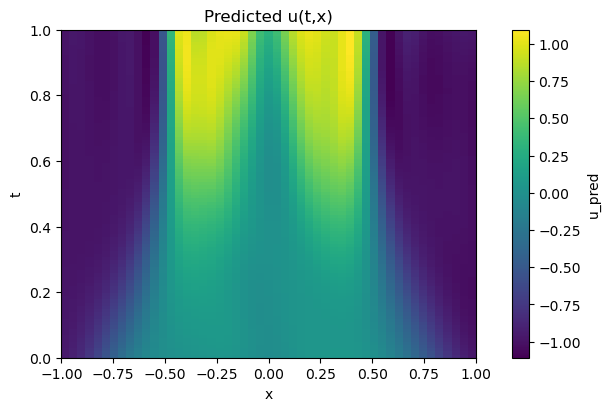

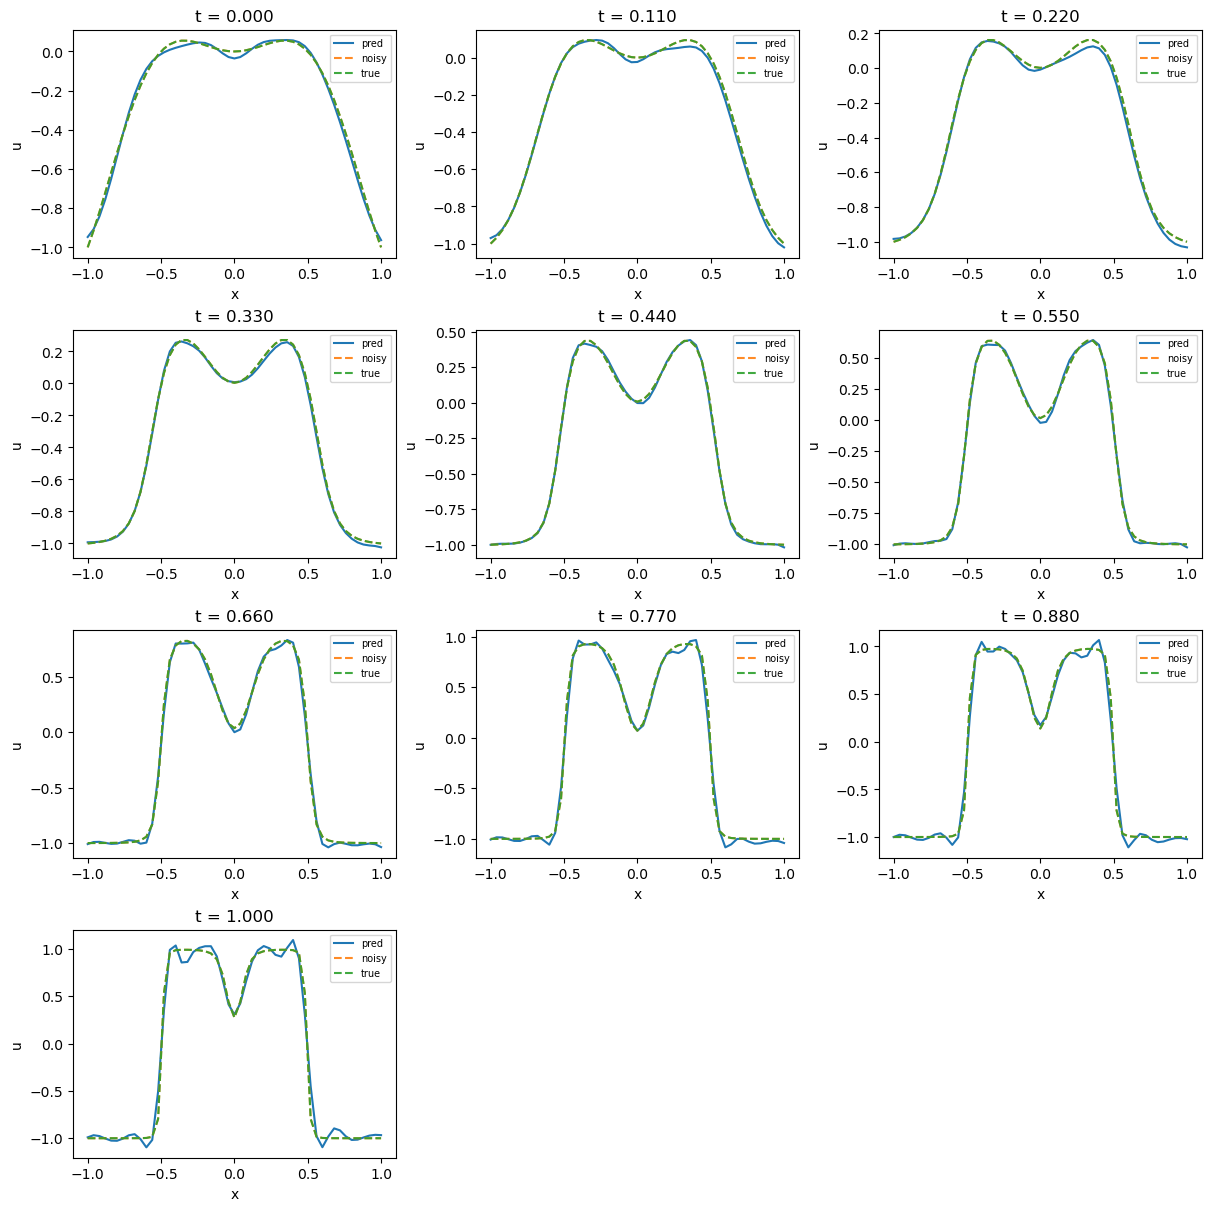

In [90]:
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

### Burgers

In [9]:
device='cpu'

# Data generation settings
path = "../Datasets/data/raw/burgers.mat"
noise=0.0
stride_t=1
stride_x=5
part_num=1
which_part=1
seed=1432

partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

c:\Users\Ethan\Desktop\Research\pde_stuff\notebook\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


In [10]:
print("t_torch.shape: {}".format(t_torch.shape))
print("x_torch.shape: {}".format(x_torch.shape))

t_torch.shape: torch.Size([5252])
x_torch.shape: torch.Size([5252])


In [11]:
selected_derivs=('u','u_x','u_xx') # up to first order derivative inputs
lr=0.001
batch_size=1000  # number of data points used on optimization step 
                 # data points are generated according to tensor.randint over spacetime mesh
lam_pde=0.0
lam_reg=0.0
lam_tv=0.0
lam_data=10.0

#output settings
log_every=1000

# Initializing u_model and a dummy v_model so that trainer works
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=0, bias=False) # dummy v_model for working code
for param in v_model.parameters(): #freeze v_model params
    param.requires_grad = False
# print('v model parameters (weights) are not receiving gradients (improve data fit accuracy)')

train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

c:\Users\Ethan\anaconda3\envs\pythonProject\lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [12]:
for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                           t_torch=t_torch,
                                           x_torch=x_torch,
                                           y_clean=y_torch,
                                           y_noisy=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.09054037183523178 pde_loss=0.0853409618139267


KeyboardInterrupt: 

loss is about 1.32 e-5

max_abs_diff = 0.0440329


()

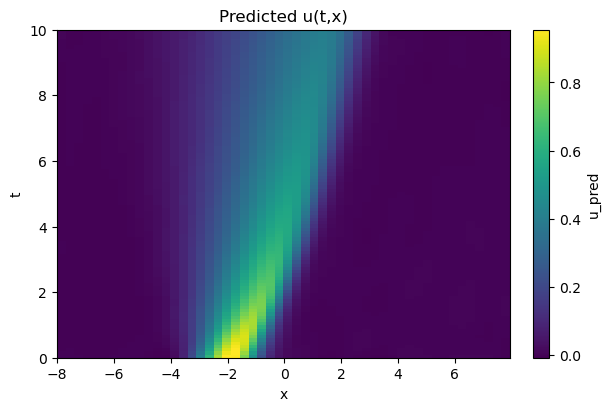

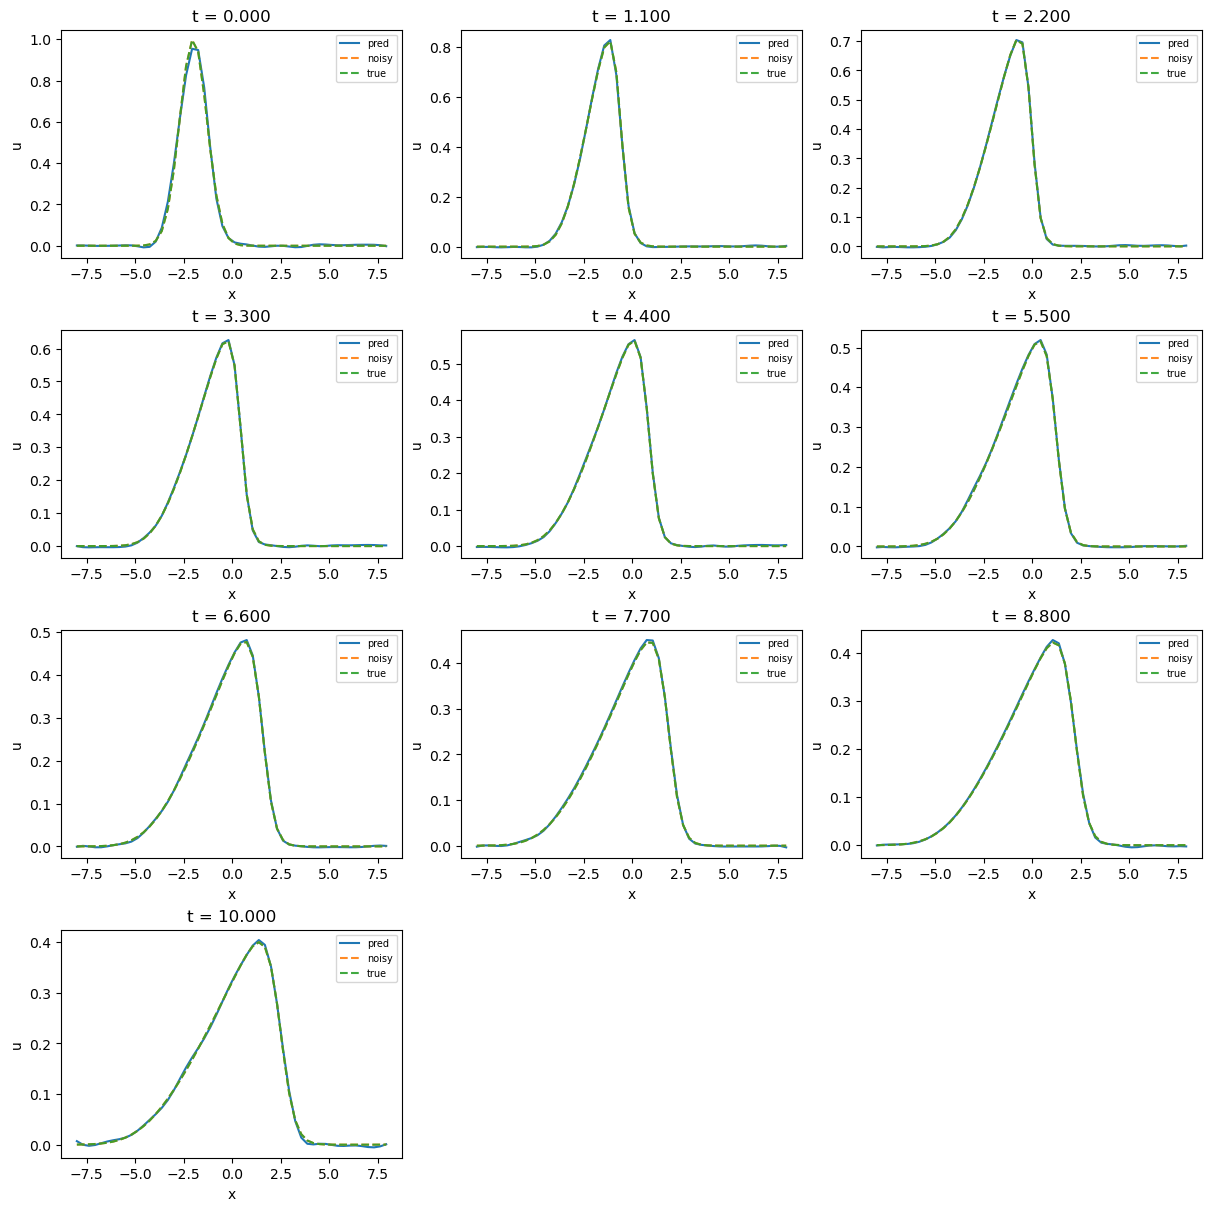

In [85]:
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

## Test **3**:
We will pretrain the data (u-net), then we will hardcode the exact correct weights into the symnet (that recovers PDE completely). Then we will pass one forward into the symnet containing the correct weights, and look at the PDE loss. Ideally, it should be less than 10^-4

### Burgers

In [21]:
device='cpu'

# Data generation settings
path = "../Datasets/data/raw/burgers.mat"
noise=0.0
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

selected_derivs=('u','u_x','u_xx') # up to first order derivative inputs
lr=0.001
batch_size=1000  # number of data points used on optimization step 
                 # data points are generated according to tensor.randint over spacetime mesh
lam_pde=0.0
lam_reg=0.0
lam_tv=0.0
lam_data=10.0

#output settings
log_every=1000

# Initializing u_model and a dummy v_model so that trainer works
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=0, bias=False) # dummy v_model for working code
for param in v_model.parameters(): #freeze v_model params
    param.requires_grad = False
# print('v model parameters (weights) are not receiving gradients (improve data fit accuracy)')

train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)

for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                           t_torch=t_torch,
                                           x_torch=x_torch,
                                           y_clean=y_torch,
                                           y_noisy=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

c:\Users\Ethan\Desktop\Research\pde_stuff\notebook\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


step 0 data_loss=0.08526655286550522 pde_loss=0.1428852379322052
step 1000 data_loss=7.604689744766802e-05 pde_loss=0.12993250787258148


KeyboardInterrupt: 

In [22]:
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, num_layers=1, bias=False)

with torch.no_grad():
    symnet.linears[0].weight.copy_(torch.tensor([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]], dtype=symnet.linears[0].weight.dtype, device=symnet.linears[0].weight.device))
    symnet.readout.weight.copy_(torch.tensor([[0.0, 0, 0.02, -1.00]], dtype=symnet.readout.weight.dtype, device=symnet.readout.weight.device))

In [23]:
symnet_error = train.mse(train.u_t,symnet(train.F))

In [24]:
print(symnet_error)

tensor(0.0007, grad_fn=<MseLossBackward0>)


### Allen Cahn

In [ ]:
device='cpu'

# Data generation settings
path = "../Datasets/data/raw/Allen_Cahn.mat"
noise=0.0
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

## Test **4**:

We'll try to change our activation function, and see if that changes performance for allen cahn